# 第 9 章 · Self-Attention 与字符 LM

[章节网页](../ch9.html)

## 运行内容

- 输出 attention 矩阵
- 运行字符 bigram 预测

## 0. 环境与数据

In [1]:
# 准备运行时：若下载单个 ipynb 后本地没有 labs/，会自动拉取所需脚本和数据。
import importlib.util
import subprocess
import sys
from pathlib import Path
from urllib.request import urlretrieve

BASE_URL = "https://raw.githubusercontent.com/zhesun-0209/ai-thinking-labs/main"
RUNTIME_FILES = ['labs/ch09/bpe.py', 'labs/ch09/language.py', 'labs/common/campus_graph.json', 'labs/common/ch6_kg.json', 'labs/common/ch6_rules.json', 'labs/common/codelens.py', 'labs/common/luxun_bpe.json', 'labs/common/mpl_setup.py', 'labs/common/notebook_helpers.py', 'labs/common/viz_anim.py']

ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if not (ROOT / "labs").exists():
    ROOT = Path.cwd() / "_ai_thinking_labs_runtime"
    for rel in RUNTIME_FILES:
        target = ROOT / rel
        if target.exists():
            continue
        target.parent.mkdir(parents=True, exist_ok=True)
        urlretrieve(f"{BASE_URL}/{rel}", target)

missing = []
for module, package in [
    ("numpy", "numpy>=1.24"),
    ("pandas", "pandas>=2.0"),
    ("matplotlib", "matplotlib>=3.7"),
    ("scipy", "scipy>=1.10"),
    ("sklearn", "scikit-learn>=1.3"),
]:
    if importlib.util.find_spec(module) is None:
        missing.append(package)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch09"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
print("runtime ready:", ROOT)
from language import *

runtime ready: /Users/zhesun/Desktop/Fudan/phd/vibe coding


In [2]:
# 输出 self-attention 的小矩阵。
display(self_attention_matrix())

,token,score,alpha
0,鲁迅,1.2,0.39
1,写,0.3,0.16
2,了,0.1,0.13
3,狂人,0.4,0.18
4,日记,0.2,0.14


token map: t0=鲁迅, t1=写, t2=了, t3=狂人, t4=日记


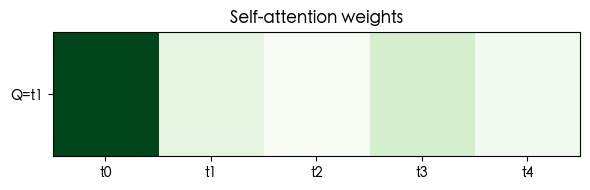

In [3]:
# 绘制 attention heatmap。
plot_attention_heatmap()

## 1. 字符语言模型

In [4]:
# 运行字符 bigram 统计并输出下一字符预测。
char_lm_demo()

字符 bigram（下一字符预测）:
  P(迅 | 鲁)
  P(写 | 迅)
  P(了 | 写)
  P(狂 | 了)
  P(人 | 狂)
  P(日 | 人)
  P(记 | 日)
